In [351]:
#load in necessary python packages
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr
import statsmodels.api as sm

In [352]:
#load in dataset as panda dataframe
dataframe = pd.read_csv('all_data.csv')
#rename life expectancy
dataframe.rename(columns={'Life expectancy at birth (years)': 'Life_Expectancy'}, inplace=True)
#print(dataframe.head())

First Visualization -- Life Expectancy & GDP Over Time Per Country

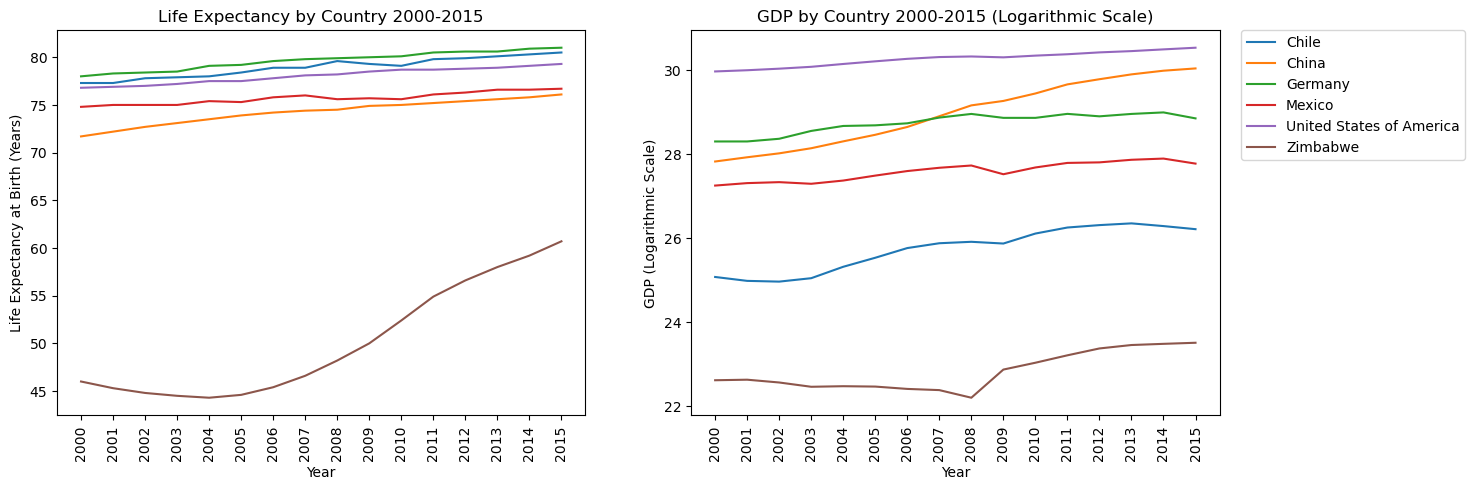

In [451]:
log_gdp = np.log(dataframe.GDP)
fig, axes = plt.subplots(1, 2, figsize=(15,5))
year_list = dataframe.Year.unique()

#Graph 1 - life expectancy over time
axes[0] = sns.lineplot(ax=axes[0], data=dataframe, x='Year', y='Life_Expectancy', hue='Country')
axes[0].set(xticks=year_list, xticklabels=year_list, title='Life Expectancy by Country 2000-2015', ylabel='Life Expectancy at Birth (Years)')
axes[0].tick_params(axis='x', labelrotation=90)

#Graph 2 - GDP over time
axes[1] = sns.lineplot(ax=axes[1], data=dataframe, x='Year', y=log_gdp, hue='Country')
axes[1].set(xticks=year_list, xticklabels=year_list, title='GDP by Country 2000-2015 (Logarithmic Scale)', ylabel='GDP (Logarithmic Scale)')
axes[1].tick_params(axis='x', labelrotation=90)

#clean up legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.91, 0.75))
axes[0].get_legend().remove()
axes[1].get_legend().remove()

Distribution of Life Expectancy and GDP

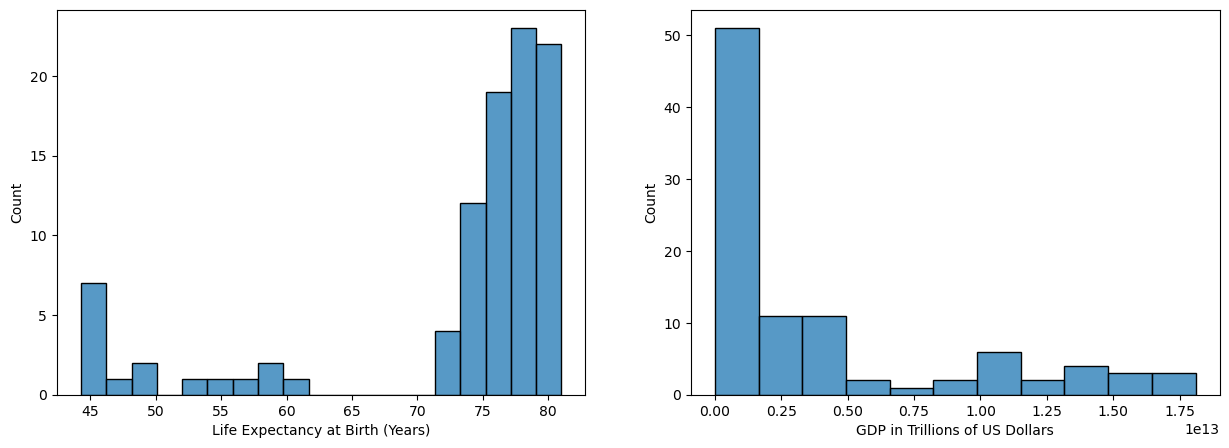

<Figure size 640x480 with 0 Axes>

In [385]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

axes[0] = sns.histplot(data=dataframe.Life_Expectancy, ax=axes[0])
axes[0].set_xlabel('Life Expectancy at Birth (Years)')
axes[1] = sns.histplot(data=dataframe.GDP, ax=axes[1])
axes[1].set_xlabel('GDP in Trillions of US Dollars')
plt.show()
plt.clf()

Comparison of Spread by Country -- Life Expectancy and GDP

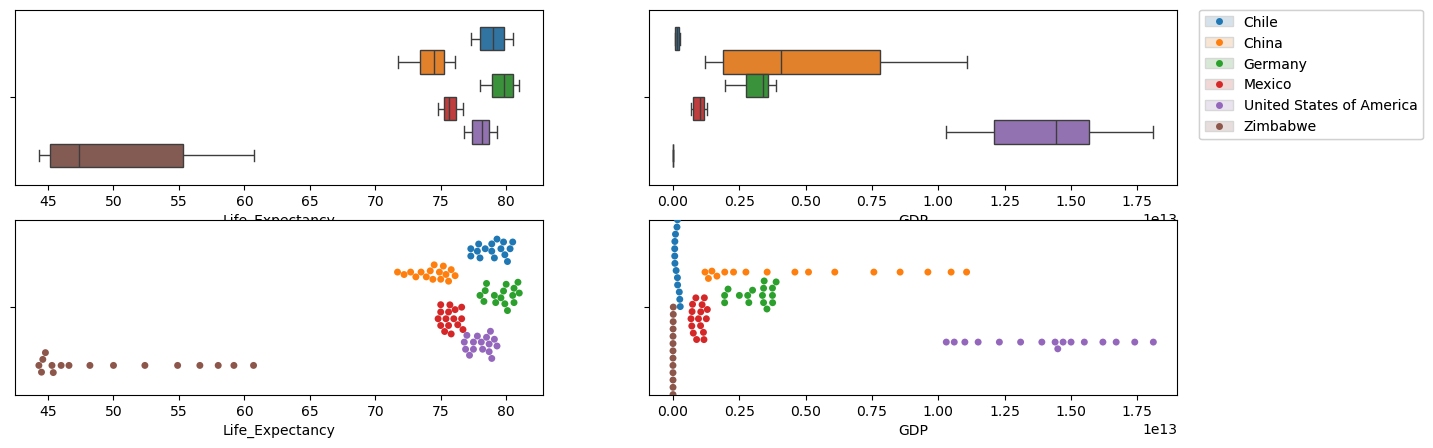

<Figure size 640x480 with 0 Axes>

In [514]:
fig, axes = plt.subplots(2, 2, figsize=(15,5))
axes[0][0] = sns.boxplot(data=dataframe, x=dataframe['Life_Expectancy'], hue='Country', ax=axes[0][0])
axes[0][1] = sns.boxplot(data=dataframe, x=dataframe['GDP'], hue='Country', ax=axes[0][1])
axes[1][0] = sns.swarmplot(data=dataframe, x=dataframe['Life_Expectancy'], hue='Country', dodge=True, ax=axes[1][0])
axes[1][1] = sns.swarmplot(data=dataframe, x=dataframe['GDP'], hue='Country', dodge=True, ax=axes[1][1])

#clean up legend
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.91, 0.75))
axes[0][0].get_legend().remove()
axes[0][1].get_legend().remove()

handles, labels = axes[1][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.91, 0.75))
axes[1][0].get_legend().remove()
axes[1][1].get_legend().remove()

plt.show()
plt.clf()

Who experienced the most growth in either category?

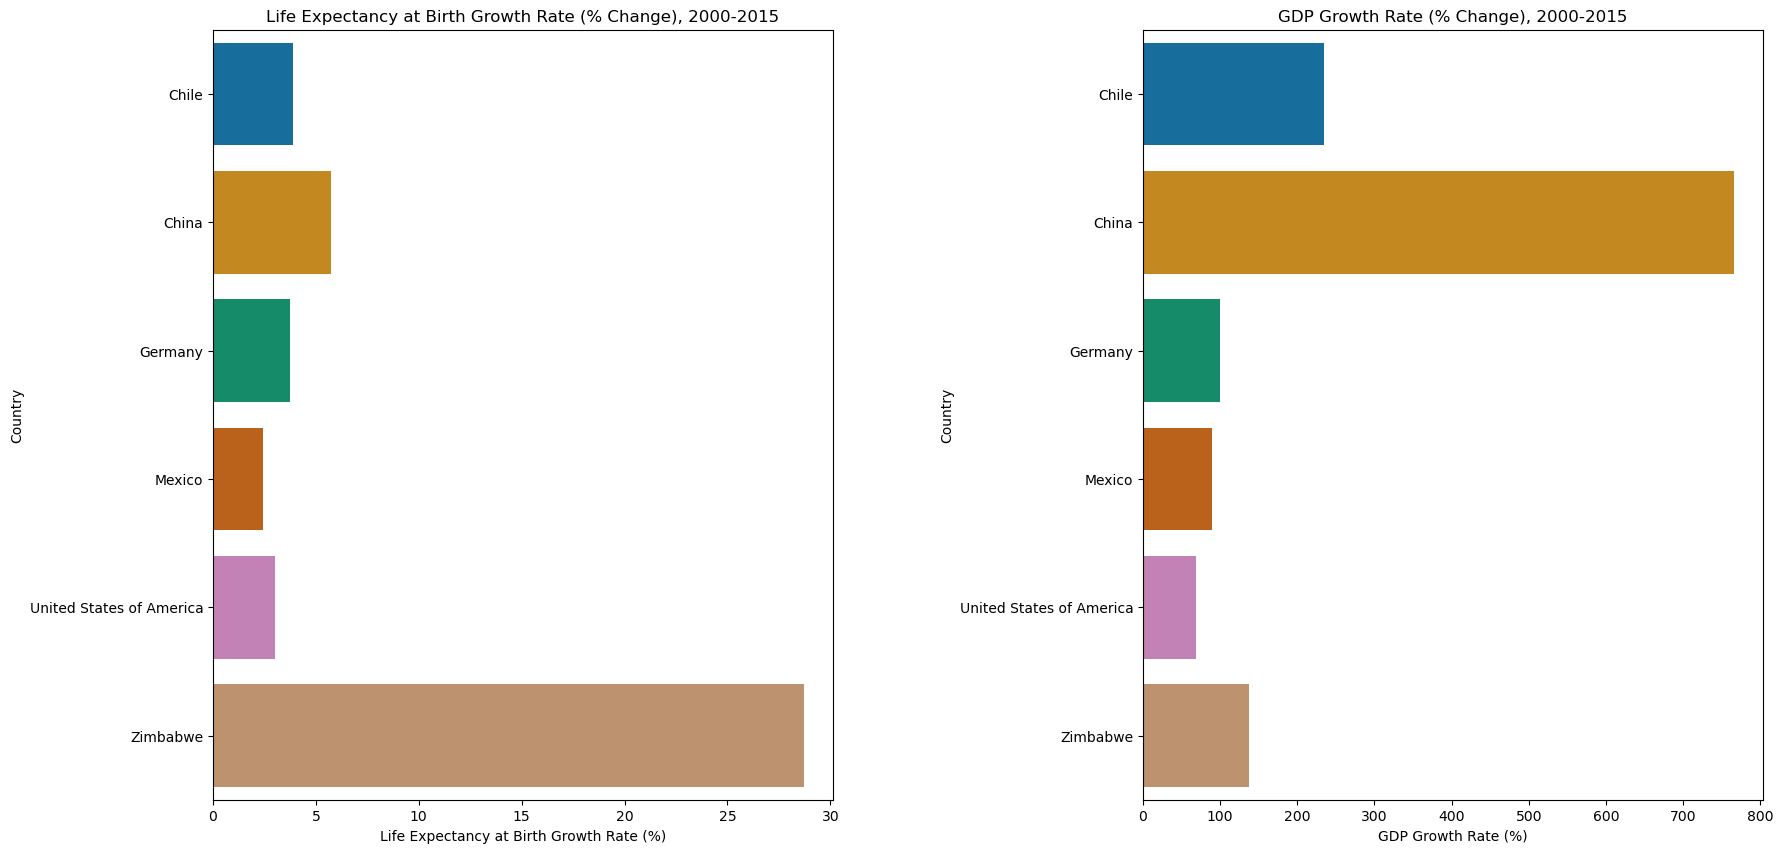

<Figure size 640x480 with 0 Axes>

In [499]:
growth_dict = {'Country': [], 'LEABY_Growth': [], 'GDP_Growth': []}

for country in countries:
    leaby_2000 = dataframe[(dataframe.Country == country) & (dataframe.Year == 2000)].Life_Expectancy.iloc[0]
    leaby_2014 = dataframe[(dataframe.Country == country) & (dataframe.Year == 2014)].Life_Expectancy.iloc[0]
    gdp_2000 = dataframe[(dataframe.Country == country) & (dataframe.Year == 2000)].GDP.iloc[0]
    gdp_2014 = dataframe[(dataframe.Country == country) & (dataframe.Year == 2014)].GDP.iloc[0]
    
    growth_dict['Country'].append(country)
    growth_dict['LEABY_Growth'].append((leaby_2014 - leaby_2000)/leaby_2000 * 100)
    growth_dict['GDP_Growth'].append((gdp_2014 - gdp_2000)/gdp_2000 * 100)
    
growth_df = pd.DataFrame.from_dict(growth_dict)

fig, axes=plt.subplots(1, 2, figsize=(20,10))
plt.subplots_adjust(wspace=0.5)

axes[0] = sns.barplot(x='LEABY_Growth', y='Country', hue='Country', data=growth_dict, palette='colorblind', legend=False, ax=axes[0])
axes[0].set(title='Life Expectancy at Birth Growth Rate (% Change), 2000-2015', xlabel='Life Expectancy at Birth Growth Rate (%)')
axes[1] = sns.barplot(x='GDP_Growth', y='Country', hue='Country', data=growth_dict, palette='colorblind', legend=False, ax=axes[1])
axes[1].set(title='GDP Growth Rate (% Change), 2000-2015', xlabel='GDP Growth Rate (%)')
plt.show()
plt.clf()

Correlation Between Life Expectancy and GDP Per Country, as measured using Pearson Correlation

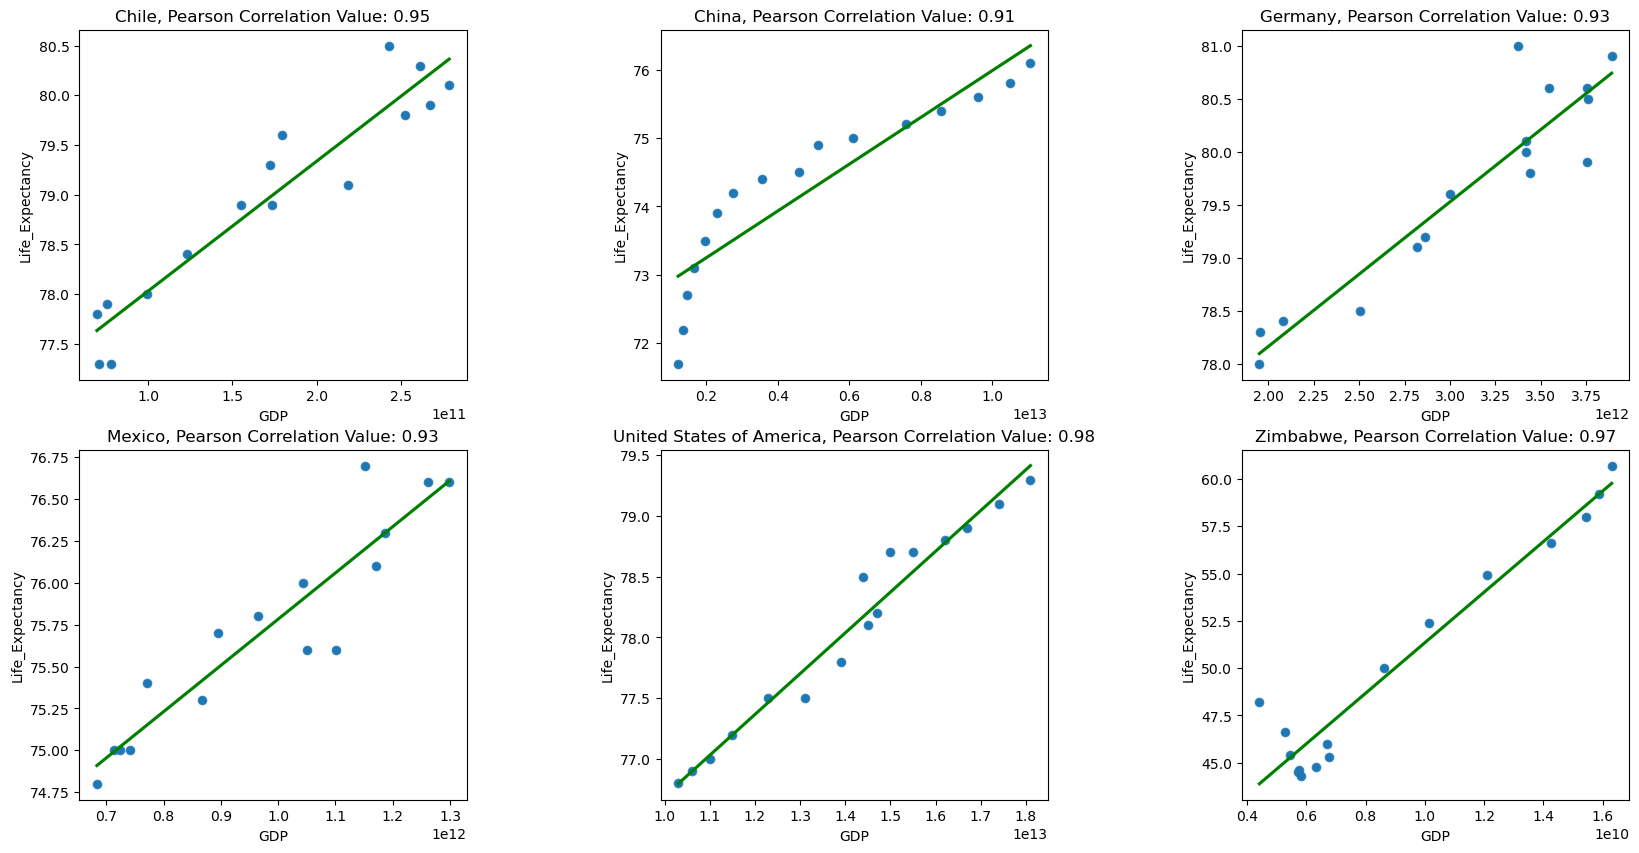

In [502]:
#correlation between life expectancy and GDP per country
countries = dataframe['Country'].unique()
fig, axes = plt.subplots(2, 3, figsize=(20,10))
plt.subplots_adjust(wspace=0.5)

#use for loop to create a plot for each country
for i, ax in enumerate(axes.flatten()):
    country_df = dataframe[dataframe['Country'] == countries[i]]
    corr_variable, p = pearsonr(country_df['GDP'], country_df['Life_Expectancy'])
    corr_variable = round(corr_variable, 2)
    sns.scatterplot(data=country_df, x='GDP', y='Life_Expectancy', ax=ax)
    sns.regplot(data=country_df, x='GDP', y='Life_Expectancy', line_kws={'color': 'g'}, ax=ax, ci=None)
    ax.set_title(countries[i] + ', Pearson Correlation Value: ' + str(corr_variable))
    
plt.show()